<a href="https://colab.research.google.com/github/josekaneto/2ESR-Engenharia-de-Software/blob/main/Data_Science_Statistical_Computing/Batalha_de_graficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ds = pd.read_csv('dataset_futebol-1.csv')

In [ ]:
ds.head(100)

,ID_Jogador,Nome_Jogador,Posição,Gols_Marcados,Assistências,Faltas_Cometidas,Minutos_Jogados,Número_da_Camisa,Altura_cm,Peso_kg
0,1,Jogador D,Goleiro,21,8,3,2690,36,162.797264,60.707512
1,2,Jogador B,Meia,27,2,1,1416,84,185.606729,84.102127
2,3,Jogador C,Defensor,19,9,1,3375,68,170.845897,74.591929
3,4,Jogador D,Meia,0,18,8,3152,7,183.712480,75.458434
4,5,Jogador D,Atacante,9,2,4,1996,54,187.205277,82.577644
...,...,...,...,...,...,...,...,...,...,...
95,96,Jogador A,Meia,17,11,8,2859,49,197.457967,78.477877
96,97,Jogador C,Goleiro,18,14,4,3812,60,195.044208,99.663536
97,98,Jogador C,Defensor,21,14,0,944,2,171.110105,98.829998
98,99,Jogador A,Goleiro,4,5,9,2845,60,194.057946,97.692616


In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Jogador        100 non-null    int64  
 1   Nome_Jogador      100 non-null    object 
 2   Posição           100 non-null    object 
 3   Gols_Marcados     100 non-null    int64  
 4   Assistências      100 non-null    int64  
 5   Faltas_Cometidas  100 non-null    int64  
 6   Minutos_Jogados   100 non-null    int64  
 7   Número_da_Camisa  100 non-null    int64  
 8   Altura_cm         100 non-null    float64
 9   Peso_kg           100 non-null    float64
dtypes: float64(2), int64(6), object(2)
memory usage: 7.9+ KB


In [ ]:
gols_assistencias_por_minuto = ds.copy()

In [ ]:
gols_assistencias_por_minuto.head(100)

,ID_Jogador,Nome_Jogador,Posição,Gols_Marcados,Assistências,Faltas_Cometidas,Minutos_Jogados,Número_da_Camisa,Altura_cm,Peso_kg
0,1,Jogador D,Goleiro,21,8,3,2690,36,162.797264,60.707512
1,2,Jogador B,Meia,27,2,1,1416,84,185.606729,84.102127
2,3,Jogador C,Defensor,19,9,1,3375,68,170.845897,74.591929
3,4,Jogador D,Meia,0,18,8,3152,7,183.712480,75.458434
4,5,Jogador D,Atacante,9,2,4,1996,54,187.205277,82.577644
...,...,...,...,...,...,...,...,...,...,...
95,96,Jogador A,Meia,17,11,8,2859,49,197.457967,78.477877
96,97,Jogador C,Goleiro,18,14,4,3812,60,195.044208,99.663536
97,98,Jogador C,Defensor,21,14,0,944,2,171.110105,98.829998
98,99,Jogador A,Goleiro,4,5,9,2845,60,194.057946,97.692616


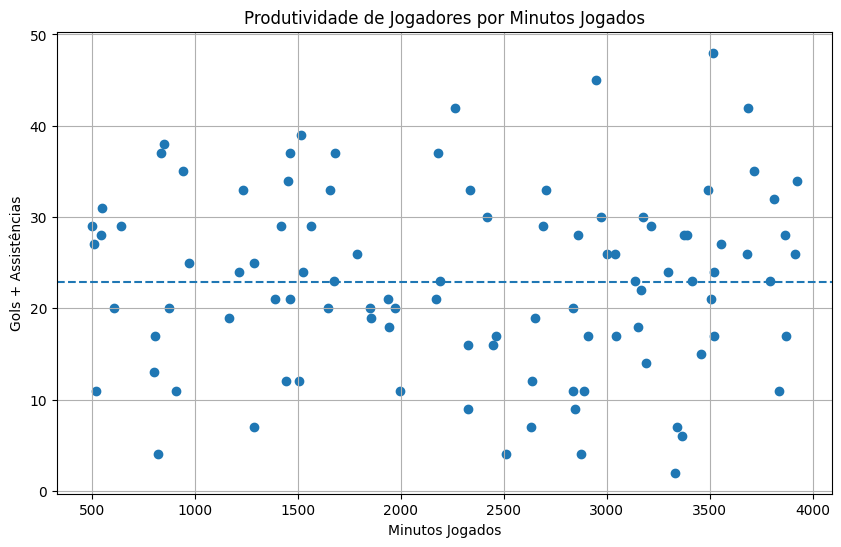

In [ ]:
gols_assistencias_por_minuto['Gols + Assistências'] = gols_assistencias_por_minuto['Gols_Marcados'] + gols_assistencias_por_minuto['Assistências']

media_gols_assistencias_por_minuto = gols_assistencias_por_minuto['Gols + Assistências'].mean()

plt.figure(figsize=(10, 6))
plt.scatter(gols_assistencias_por_minuto['Minutos_Jogados'], gols_assistencias_por_minuto['Gols + Assistências'])
plt.axhline(media_gols_assistencias_por_minuto, linestyle="--", label=f"Média ({media_gols_assistencias_por_minuto:.2f})")
plt.xlabel('Minutos Jogados')
plt.ylabel('Gols + Assistências')
plt.title('Produtividade de Jogadores por Minutos Jogados')
plt.grid(True)
plt.show()

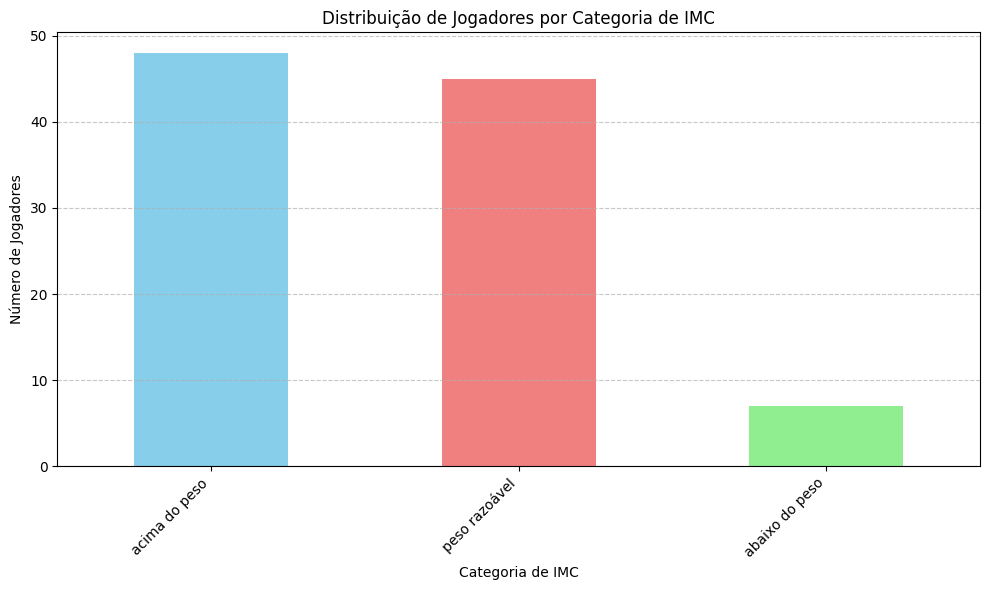

In [ ]:
imc_jogadores = ds.copy()

imc_jogadores['Altura_m'] = imc_jogadores['Altura_cm'] / 100
imc_jogadores['IMC'] = imc_jogadores['Peso_kg'] / (imc_jogadores['Altura_m'] ** 2)

bins = [0, 18.5, 25.0, imc_jogadores['IMC'].max() + 1]
labels = ['abaixo do peso', 'peso razoável', 'acima do peso']

imc_jogadores['Categoria_IMC'] = pd.cut(imc_jogadores['IMC'], bins=bins, labels=labels, right=False)

categorias_imc = imc_jogadores['Categoria_IMC'].unique()
num_categorias = len(categorias_imc)

bmi_category_counts = imc_jogadores['Categoria_IMC'].value_counts()

plt.figure(figsize=(10, 6))
bmi_category_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribuição de Jogadores por Categoria de IMC')
plt.xlabel('Categoria de IMC')
plt.ylabel('Número de Jogadores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

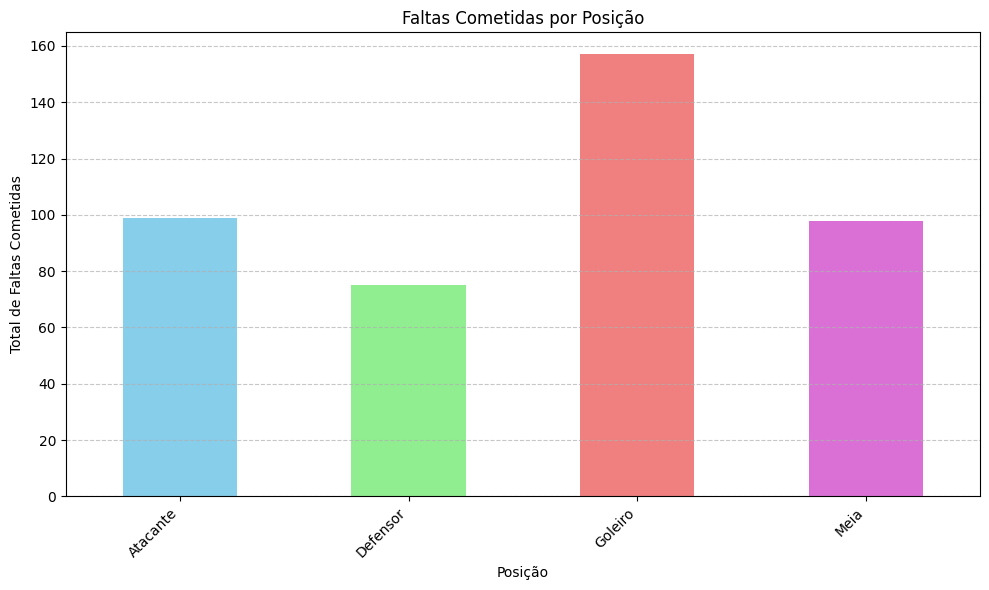

In [ ]:
faltas_cometidas_por_posicao_ds = ds.copy()

faltas_cometidas_por_posicao = faltas_cometidas_por_posicao_ds.groupby('Posição')[['Gols_Marcados', 'Faltas_Cometidas']].sum()

plt.figure(figsize=(10, 6))
faltas_cometidas_por_posicao['Faltas_Cometidas'].plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral', 'orchid'])
plt.title('Faltas Cometidas por Posição')
plt.xlabel('Posição')
plt.ylabel('Total de Faltas Cometidas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()